In [1]:
# ==========================================================
# CELL 1
# Import all required libraries
# ==========================================================

print("Starting cell #1")
import os
import json
import copy
import pickle
import random
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from tqdm.auto import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from torch.ao.quantization import quantize_dynamic

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    XLMRobertaConfig,
    XLMRobertaModel,
    get_linear_schedule_with_warmup
)

warnings.filterwarnings("ignore")

print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
# ==========================================================
# CELL 2
# Set Kaggle dataset file names and dataset discovery hint
# ==========================================================

print("Starting cell #2")
# -----------------------------
# Kaggle dataset file names
# -----------------------------
TRAIN_FILENAME = "train.csv"
VAL_FILENAME = "validation.csv"
TEST_FILENAME = "test.csv"

# Optional hint to prioritize the correct Kaggle dataset folder
# Example: if your dataset path contains ".../dataset/..."
DATASET_NAME_HINT = "dataset"

print("Executed cell #2")

Starting cell #2
Executed cell #2


In [3]:
# ==========================================================
# CELL 3
# Set model hyperparameters, training settings, and save directory
# Faster training + stronger student initialization
# ==========================================================

print("Starting cell #3")
# -----------------------------
# Model settings
# -----------------------------
TEACHER_MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 128

# -----------------------------
# Student architecture
# Use a PRETRAINED truncated XLM-R student
# First 6 layers of pretrained xlm-roberta-base
# -----------------------------
STUDENT_USE_PRETRAINED = True
STUDENT_HIDDEN_SIZE = 768
STUDENT_NUM_LAYERS = 6
STUDENT_NUM_HEADS = 12
STUDENT_INTERMEDIATE_SIZE = 3072
DROPOUT = 0.1

# -----------------------------
# Multi-GPU batch settings
# -----------------------------
PER_GPU_BATCH_SIZE = 8
GRAD_CLIP = 1.0

# -----------------------------
# Training settings
# -----------------------------
TEACHER_EPOCHS = 3
STUDENT_EPOCHS = 5

TEACHER_LR = 2e-5
STUDENT_ENCODER_LR = 1e-5
STUDENT_HEAD_LR = 5e-5
WEIGHT_DECAY = 0.01
LABEL_SMOOTHING = 0.05

# -----------------------------
# Loss weights
# total_loss = CE + alpha*KD + beta*RowAlign + gamma*SupCon
# Use gentler weights than before
# -----------------------------
ALPHA_KD = 0.40
BETA_ROW_ALIGN = 0.05
GAMMA_SUPCON = 0.05

TEMPERATURE_KD = 2.0
ROW_ALIGN_TEMPERATURE = 0.07
SUPCON_TEMPERATURE = 0.07

# -----------------------------
# Speed / stability settings
# -----------------------------
USE_AMP = True
EARLY_STOPPING_PATIENCE = 2
TEACHER_PRECOMPUTE_BATCH_SIZE = 32

# -----------------------------
# Misc
# -----------------------------
SEED = 42
NUM_WORKERS = 4
SAVE_DIR = "/kaggle/working/multilingual_emotion_kd_contrastive_fast"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Executed cell #3")

Starting cell #3
Executed cell #3


In [4]:
# ==========================================================
# CELL 4
# Set random seeds for reproducibility
# ==========================================================

print("Starting cell #4")
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print("Executed cell #4")

Starting cell #4
Executed cell #4


In [5]:
# ==========================================================
# CELL 5
# Check GPUs and configure effective batch size
# Also enable AMP and CUDA speed flags
# ==========================================================

print("Starting cell #5")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

GPU_COUNT = torch.cuda.device_count() if torch.cuda.is_available() else 0
print("GPU count:", GPU_COUNT)

if torch.cuda.is_available():
    for i in range(GPU_COUNT):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")

BATCH_SIZE = PER_GPU_BATCH_SIZE * max(1, GPU_COUNT)
print("Per-GPU batch size:", PER_GPU_BATCH_SIZE)
print("Effective total batch size:", BATCH_SIZE)

MULTI_GPU = GPU_COUNT > 1
print("Multi-GPU enabled:", MULTI_GPU)

AMP_ENABLED = USE_AMP and (device.type == "cuda")
print("AMP enabled:", AMP_ENABLED)

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

print("Executed cell #5")

Starting cell #5
Using device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Per-GPU batch size: 8
Effective total batch size: 16
Multi-GPU enabled: True
AMP enabled: True
Executed cell #5


In [6]:
# ==========================================================
# CELL 6
# Define Kaggle CSV path resolver and required dataset columns
# ==========================================================

print("Starting cell #6")
from pathlib import Path
import re
import pandas as pd
from sklearn.preprocessing import LabelEncoder

REQUIRED_COLUMNS = [
    "Label",
    "Bengali",
    "Banglish",
    "English"
]

def resolve_kaggle_csv(filename, dataset_name_hint="dataset"):
    """
    Search Kaggle mounted folders and pick the best matching CSV file.
    Priority:
    1) paths containing dataset_name_hint
    2) paths under /kaggle/input
    3) alphabetical order
    """
    search_roots = [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        Path("/kaggle")
    ]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(filename))

    matches = sorted(set(str(p) for p in matches))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {filename} under /kaggle/input or related Kaggle folders."
        )

    def score_path(path_str):
        score = 0
        path_lower = path_str.lower()

        if dataset_name_hint and dataset_name_hint.lower() in path_lower:
            score += 10
        if "/kaggle/input/" in path_lower:
            score += 5
        if path_lower.endswith("/" + filename.lower()):
            score += 1

        return score

    matches = sorted(matches, key=lambda x: (-score_path(x), x))
    chosen = matches[0]

    print(f"\nCandidates found for {filename}:")
    for p in matches[:10]:
        prefix = "->" if p == chosen else "  "
        print(f"{prefix} {p}")

    return chosen

print("Executed cell #6")

Starting cell #6
Executed cell #6


In [7]:
# ==========================================================
# CELL 7
# Resolve train, validation, and test CSV file paths
# ==========================================================

print("Starting cell #7")
TRAIN_CSV = resolve_kaggle_csv(TRAIN_FILENAME, DATASET_NAME_HINT)
VAL_CSV = resolve_kaggle_csv(VAL_FILENAME, DATASET_NAME_HINT)
TEST_CSV = resolve_kaggle_csv(TEST_FILENAME, DATASET_NAME_HINT)

print("\nResolved file paths:")
print("TRAIN_CSV =", TRAIN_CSV)
print("VAL_CSV   =", VAL_CSV)
print("TEST_CSV  =", TEST_CSV)

print("Executed cell #7")

Starting cell #7

Candidates found for train.csv:
-> /kaggle/input/datasets/sajidruetcse21/dataset/train.csv

Candidates found for validation.csv:
-> /kaggle/input/datasets/sajidruetcse21/dataset/validation.csv

Candidates found for test.csv:
-> /kaggle/input/datasets/sajidruetcse21/dataset/test.csv

Resolved file paths:
TRAIN_CSV = /kaggle/input/datasets/sajidruetcse21/dataset/train.csv
VAL_CSV   = /kaggle/input/datasets/sajidruetcse21/dataset/validation.csv
TEST_CSV  = /kaggle/input/datasets/sajidruetcse21/dataset/test.csv
Executed cell #7


In [8]:
# ==========================================================
# CELL 8
# Define dataframe loading helpers with robust column normalization
# ==========================================================

print("Starting cell #8")
def normalize_colname(col):
    col = str(col).replace("\ufeff", "").strip().lower()
    col = re.sub(r"[\s\-/]+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")


def load_dataframe(path):
    df = pd.read_csv(path)

    # Clean raw column names first
    df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]

    # Robust matching, but final names stay as dataset schema names
    alias_map = {
        "label": "Label",
        "emotion_label": "Label",
        "emotion": "Label",

        "bengali": "Bengali",
        "bangla": "Bengali",
        "bangla_sentence": "Bengali",
        "bengali_sentence": "Bengali",

        "banglish": "Banglish",
        "banglish_sentence": "Banglish",

        "english": "English",
        "english_sentence": "English",
    }

    rename_map = {}
    for col in df.columns:
        norm = normalize_colname(col)
        if norm in alias_map:
            rename_map[col] = alias_map[norm]

    df = df.rename(columns=rename_map)

    missing_cols = [col for col in REQUIRED_COLUMNS if col not in df.columns]
    if missing_cols:
        raise ValueError(
            f"{path} is missing required columns: {missing_cols}\n"
            f"Available columns are: {list(df.columns)}"
        )

    df = df[REQUIRED_COLUMNS].copy()

    # No missing-value handling, as requested
    for col in REQUIRED_COLUMNS:
        df[col] = df[col].astype(str).str.strip()

    return df.reset_index(drop=True)

print("Executed cell #8")

Starting cell #8
Executed cell #8


In [9]:
# ==========================================================
# CELL 9
# Load datasets, encode emotion labels, and build class weights
# ==========================================================

print("Starting cell #9")
train_df = load_dataframe(TRAIN_CSV)
val_df = load_dataframe(VAL_CSV)
test_df = load_dataframe(TEST_CSV)

print("\nDetected dataset schema:")
print(train_df.columns.tolist())

label_encoder = LabelEncoder()
train_df["label_id"] = label_encoder.fit_transform(train_df["Label"])
val_df["label_id"] = label_encoder.transform(val_df["Label"])
test_df["label_id"] = label_encoder.transform(test_df["Label"])

num_labels = len(label_encoder.classes_)
print("\nNumber of emotion classes:", num_labels)
print("Emotion classes:", list(label_encoder.classes_))

# -----------------------------
# Class weights for imbalanced labels
# -----------------------------
label_counts = train_df["label_id"].value_counts().sort_index()
class_weights = len(train_df) / (num_labels * label_counts.values.astype(np.float32))
class_weights = torch.tensor(class_weights, dtype=torch.float32)

class_stats_df = pd.DataFrame({
    "label_id": label_counts.index,
    "label_name": [label_encoder.classes_[i] for i in label_counts.index],
    "count": label_counts.values,
    "class_weight": class_weights.numpy()
})

print("\nTraining label distribution:")
print(class_stats_df)

print("Executed cell #9")

Starting cell #9

Detected dataset schema:
['Label', 'Bengali', 'Banglish', 'English']

Number of emotion classes: 6
Emotion classes: ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']

Training label distribution:
   label_id label_name  count  class_weight
0         0      anger  10626      0.879400
1         1    disgust   9169      1.019141
2         2       fear   5295      1.764778
3         3        joy  12486      0.748398
4         4    sadness  11416      0.818544
5         5   surprise   7075      1.320777
Executed cell #9


In [10]:
# ==========================================================
# CELL 10
# Build flat classification and multilingual triplet dataframes
# ==========================================================

print("Starting cell #10")
def build_flat_classification_df(df):
    """
    Each row becomes 3 classification samples:
    Bengali, Banglish, English
    """
    records = []

    language_columns = [
        ("Bengali", "bengali"),
        ("Banglish", "banglish"),
        ("English", "english")
    ]

    for text_col, lang_name in language_columns:
        subset = df[["label_id", text_col]].copy()
        subset = subset.rename(columns={text_col: "text"})
        subset["language"] = lang_name
        records.append(subset)

    flat_df = pd.concat(records, axis=0).reset_index(drop=True)
    return flat_df


def build_triplet_alignment_df(df):
    """
    Each row stays as one multilingual triplet:
    (Bengali, Banglish, English)
    """
    triplet_df = df[
        ["label_id", "Bengali", "Banglish", "English"]
    ].copy().reset_index(drop=True)
    return triplet_df


flat_train_df = build_flat_classification_df(train_df)
flat_val_df = build_flat_classification_df(val_df)
flat_test_df = build_flat_classification_df(test_df)

triplet_train_df = build_triplet_alignment_df(train_df)
triplet_val_df = build_triplet_alignment_df(val_df)
triplet_test_df = build_triplet_alignment_df(test_df)

print(f"\nTrain rows: {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Test rows: {len(test_df)}")

print(f"Flat train samples: {len(flat_train_df)}")
print(f"Flat validation samples: {len(flat_val_df)}")
print(f"Flat test samples: {len(flat_test_df)}")

print(f"Triplet train samples: {len(triplet_train_df)}")
print(f"Triplet validation samples: {len(triplet_val_df)}")
print(f"Triplet test samples: {len(triplet_test_df)}")

print("Executed cell #10")

Starting cell #10

Train rows: 56067
Validation rows: 7929
Test rows: 16101
Flat train samples: 168201
Flat validation samples: 23787
Flat test samples: 48303
Triplet train samples: 56067
Triplet validation samples: 7929
Triplet test samples: 16101
Executed cell #10


In [11]:
# ==========================================================
# CELL 11
# Load tokenizer and define flat text dataset + dynamic padding collator
# ==========================================================

print("Starting cell #11")
tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_NAME)


class FlatEmotionDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        required_cols = ["text", "label_id", "language"]
        missing_cols = [col for col in required_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(
                f"FlatEmotionDataset is missing columns: {missing_cols}\n"
                f"Available columns: {list(df.columns)}"
            )

        self.texts = df["text"].astype(str).tolist()
        self.labels = df["label_id"].astype(int).tolist()
        self.languages = df["language"].astype(str).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoded = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False
        )

        item = {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
            "labels": label
        }
        return item


@dataclass
class FlatEmotionCollator:
    tokenizer: object
    pad_to_multiple_of: int = 8

    def __call__(self, features):
        labels = [f["labels"] for f in features]
        token_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            token_features,
            padding=True,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt"
        )
        batch["labels"] = torch.tensor(labels, dtype=torch.long)
        return batch

print("Executed cell #11")

Starting cell #11


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Executed cell #11


In [12]:
# ==========================================================
# CELL 12
# Define multilingual triplet dataset + dynamic padding collator
# Supports optional precomputed teacher logits
# ==========================================================

print("Starting cell #12")
class TripletEmotionDataset(Dataset):
    def __init__(
        self,
        df,
        tokenizer,
        max_length=128,
        teacher_logits_bangla=None,
        teacher_logits_banglish=None,
        teacher_logits_english=None
    ):
        bangla_col = self._find_column(df, ["Bengali", "bangla_sentence", "bengali_sentence", "bangla"])
        banglish_col = self._find_column(df, ["Banglish", "banglish_sentence", "banglish"])
        english_col = self._find_column(df, ["English", "english_sentence", "english"])

        if "label_id" not in df.columns:
            raise ValueError(
                f"TripletEmotionDataset requires 'label_id'. "
                f"Available columns: {list(df.columns)}"
            )

        self.bangla = df[bangla_col].astype(str).tolist()
        self.banglish = df[banglish_col].astype(str).tolist()
        self.english = df[english_col].astype(str).tolist()
        self.labels = df["label_id"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.teacher_logits_bangla = teacher_logits_bangla
        self.teacher_logits_banglish = teacher_logits_banglish
        self.teacher_logits_english = teacher_logits_english

        if self.teacher_logits_bangla is not None:
            assert len(self.teacher_logits_bangla) == len(self.labels)
            assert len(self.teacher_logits_banglish) == len(self.labels)
            assert len(self.teacher_logits_english) == len(self.labels)

        print(
            f"TripletEmotionDataset column mapping -> "
            f"Bangla: {bangla_col}, Banglish: {banglish_col}, English: {english_col}"
        )

    @staticmethod
    def _find_column(df, candidates):
        for col in candidates:
            if col in df.columns:
                return col
        raise ValueError(
            f"None of the expected columns were found: {candidates}\n"
            f"Available columns: {list(df.columns)}"
        )

    def encode_text(self, text):
        encoded = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False
        )
        return {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"]
        }

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            "bangla": self.encode_text(self.bangla[idx]),
            "banglish": self.encode_text(self.banglish[idx]),
            "english": self.encode_text(self.english[idx]),
            "labels": self.labels[idx]
        }

        if self.teacher_logits_bangla is not None:
            item["teacher_logits_bangla"] = self.teacher_logits_bangla[idx]
            item["teacher_logits_banglish"] = self.teacher_logits_banglish[idx]
            item["teacher_logits_english"] = self.teacher_logits_english[idx]

        return item


@dataclass
class TripletEmotionCollator:
    tokenizer: object
    pad_to_multiple_of: int = 8

    def __call__(self, features):
        bangla_features = [f["bangla"] for f in features]
        banglish_features = [f["banglish"] for f in features]
        english_features = [f["english"] for f in features]
        labels = [f["labels"] for f in features]

        bangla_batch = self.tokenizer.pad(
            bangla_features,
            padding=True,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt"
        )
        banglish_batch = self.tokenizer.pad(
            banglish_features,
            padding=True,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt"
        )
        english_batch = self.tokenizer.pad(
            english_features,
            padding=True,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt"
        )

        batch = {
            "bangla_input_ids": bangla_batch["input_ids"],
            "bangla_attention_mask": bangla_batch["attention_mask"],
            "banglish_input_ids": banglish_batch["input_ids"],
            "banglish_attention_mask": banglish_batch["attention_mask"],
            "english_input_ids": english_batch["input_ids"],
            "english_attention_mask": english_batch["attention_mask"],
            "labels": torch.tensor(labels, dtype=torch.long)
        }

        if "teacher_logits_bangla" in features[0]:
            batch["teacher_logits_bangla"] = torch.stack(
                [f["teacher_logits_bangla"] for f in features]
            ).float()
            batch["teacher_logits_banglish"] = torch.stack(
                [f["teacher_logits_banglish"] for f in features]
            ).float()
            batch["teacher_logits_english"] = torch.stack(
                [f["teacher_logits_english"] for f in features]
            ).float()

        return batch

print("Executed cell #12")

Starting cell #12
Executed cell #12


In [13]:
# ==========================================================
# CELL 13
# Build dataset objects and dataloaders with dynamic padding
# ==========================================================

print("Starting cell #13")
# -----------------------------
# Build Dataset objects
# -----------------------------
flat_train_dataset = FlatEmotionDataset(flat_train_df, tokenizer, MAX_LENGTH)
flat_val_dataset = FlatEmotionDataset(flat_val_df, tokenizer, MAX_LENGTH)
flat_test_dataset = FlatEmotionDataset(flat_test_df, tokenizer, MAX_LENGTH)

triplet_train_dataset = TripletEmotionDataset(triplet_train_df, tokenizer, MAX_LENGTH)
triplet_val_dataset = TripletEmotionDataset(triplet_val_df, tokenizer, MAX_LENGTH)
triplet_test_dataset = TripletEmotionDataset(triplet_test_df, tokenizer, MAX_LENGTH)

# -----------------------------
# Collators
# -----------------------------
flat_collator = FlatEmotionCollator(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if AMP_ENABLED else None
)

triplet_collator = TripletEmotionCollator(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if AMP_ENABLED else None
)

# -----------------------------
# Reusable DataLoader builder
# -----------------------------
def build_loader(dataset, shuffle, collate_fn, batch_size=None):
    if batch_size is None:
        batch_size = BATCH_SIZE

    loader_kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
        "collate_fn": collate_fn
    }

    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2

    return DataLoader(dataset, **loader_kwargs)

# -----------------------------
# Build DataLoader objects
# -----------------------------
flat_train_loader = build_loader(flat_train_dataset, shuffle=True, collate_fn=flat_collator)
flat_val_loader = build_loader(flat_val_dataset, shuffle=False, collate_fn=flat_collator)
flat_test_loader = build_loader(flat_test_dataset, shuffle=False, collate_fn=flat_collator)

triplet_train_loader = build_loader(triplet_train_dataset, shuffle=True, collate_fn=triplet_collator)
triplet_val_loader = build_loader(triplet_val_dataset, shuffle=False, collate_fn=triplet_collator)
triplet_test_loader = build_loader(triplet_test_dataset, shuffle=False, collate_fn=triplet_collator)

print("Tokenizer loaded.")
print("Flat train columns:", flat_train_df.columns.tolist())
print("Triplet train columns:", triplet_train_df.columns.tolist())
print("DataLoaders created successfully.")
print("Batch size used by each DataLoader:", BATCH_SIZE)

print("Executed cell #13")

Starting cell #13
TripletEmotionDataset column mapping -> Bangla: Bengali, Banglish: Banglish, English: English
TripletEmotionDataset column mapping -> Bangla: Bengali, Banglish: Banglish, English: English
TripletEmotionDataset column mapping -> Bangla: Bengali, Banglish: Banglish, English: English
Tokenizer loaded.
Flat train columns: ['label_id', 'text', 'language']
Triplet train columns: ['label_id', 'Bengali', 'Banglish', 'English']
DataLoaders created successfully.
Batch size used by each DataLoader: 16
Executed cell #13


In [14]:
# ==========================================================
# CELL 14
# Define mean pooling and the student emotion model
# PRETRAINED truncated XLM-R student for better accuracy
# ==========================================================

print("Starting cell #14")
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class StudentEmotionModel(nn.Module):
    def __init__(
        self,
        num_labels,
        student_hidden_size=768,
        num_hidden_layers=6,
        num_attention_heads=12,
        intermediate_size=3072,
        dropout=0.1,
        pretrained_model_name=TEACHER_MODEL_NAME,
        use_pretrained=STUDENT_USE_PRETRAINED
    ):
        super().__init__()

        self.arch_config = {
            "num_labels": num_labels,
            "student_hidden_size": student_hidden_size,
            "num_hidden_layers": num_hidden_layers,
            "num_attention_heads": num_attention_heads,
            "intermediate_size": intermediate_size,
            "dropout": dropout,
            "pretrained_model_name": pretrained_model_name,
            "use_pretrained": use_pretrained
        }

        if use_pretrained:
            base_encoder = XLMRobertaModel.from_pretrained(
                pretrained_model_name,
                add_pooling_layer=False
            )

            total_layers = len(base_encoder.encoder.layer)
            if num_hidden_layers < total_layers:
                base_encoder.encoder.layer = nn.ModuleList(
                    list(base_encoder.encoder.layer[:num_hidden_layers])
                )
                base_encoder.config.num_hidden_layers = num_hidden_layers

            self.encoder = base_encoder
            hidden_size = self.encoder.config.hidden_size

        else:
            config = XLMRobertaConfig(
                vocab_size=tokenizer.vocab_size,
                hidden_size=student_hidden_size,
                num_hidden_layers=num_hidden_layers,
                num_attention_heads=num_attention_heads,
                intermediate_size=intermediate_size,
                max_position_embeddings=514,
                hidden_dropout_prob=dropout,
                attention_probs_dropout_prob=dropout,
                pad_token_id=tokenizer.pad_token_id,
                bos_token_id=tokenizer.bos_token_id,
                eos_token_id=tokenizer.eos_token_id
            )
            self.encoder = XLMRobertaModel(config, add_pooling_layer=False)
            hidden_size = student_hidden_size

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        encoder_outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        sentence_embedding = mean_pooling(
            encoder_outputs.last_hidden_state,
            attention_mask
        )

        logits = self.classifier(self.dropout(sentence_embedding))

        return {
            "embeddings": sentence_embedding,
            "logits": logits
        }

print("Executed cell #14")

Starting cell #14
Executed cell #14


In [15]:
# ==========================================================
# CELL 15
# Initialize teacher and student models and report parameter counts
# ==========================================================

print("Starting cell #15")
def get_base_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


def count_parameters(model):
    base_model = get_base_model(model)
    total_params = sum(p.numel() for p in base_model.parameters())
    trainable_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
    return total_params, trainable_params


teacher_model = AutoModelForSequenceClassification.from_pretrained(
    TEACHER_MODEL_NAME,
    num_labels=num_labels
).to(device)

student_model = StudentEmotionModel(
    num_labels=num_labels,
    student_hidden_size=STUDENT_HIDDEN_SIZE,
    num_hidden_layers=STUDENT_NUM_LAYERS,
    num_attention_heads=STUDENT_NUM_HEADS,
    intermediate_size=STUDENT_INTERMEDIATE_SIZE,
    dropout=DROPOUT
).to(device)

if MULTI_GPU:
    teacher_model = nn.DataParallel(teacher_model)
    student_model = nn.DataParallel(student_model)
    print("Both teacher and student models are wrapped with nn.DataParallel")

teacher_total, teacher_trainable = count_parameters(teacher_model)
student_total, student_trainable = count_parameters(student_model)

print(f"Teacher total params: {teacher_total:,}")
print(f"Teacher trainable params: {teacher_trainable:,}")
print(f"Student total params: {student_total:,}")
print(f"Student trainable params: {student_trainable:,}")

print("Executed cell #15")

Starting cell #15


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
lm_head.dense.weight        | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
lm_head.layer_norm.weight   | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Both teacher and student models are wrapped with nn.DataParallel
Teacher total params: 278,048,262
Teacher trainable params: 278,048,262
Student total params: 234,930,438
Student trainable params: 234,930,438
Executed cell #15


In [16]:
# ==========================================================
# CELL 16
# Define classification, logits extraction, and distillation utilities
# Weighted CE + label smoothing
# ==========================================================

print("Starting cell #16")
classification_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=LABEL_SMOOTHING
)

def get_logits_from_model_output(outputs):
    if isinstance(outputs, dict):
        return outputs["logits"]
    if hasattr(outputs, "logits"):
        return outputs.logits
    if isinstance(outputs, (tuple, list)):
        for item in outputs:
            if torch.is_tensor(item) and item.dim() >= 2:
                return item
    raise ValueError("Could not extract logits from model outputs.")


def knowledge_distillation_loss(student_logits, teacher_logits, temperature=2.0):
    student_logits = student_logits.float()
    teacher_logits = teacher_logits.float().detach()

    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)

    kd_loss = F.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="batchmean"
    ) * (temperature ** 2)

    return kd_loss

print("Executed cell #16")

Starting cell #16
Executed cell #16


In [17]:
# ==========================================================
# CELL 17
# Define row-alignment and supervised contrastive loss functions
# ==========================================================

print("Starting cell #17")
class MultiPositiveRowAlignmentLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, emb_bangla, emb_banglish, emb_english):
        embeddings = torch.cat([emb_bangla, emb_banglish, emb_english], dim=0)
        embeddings = F.normalize(embeddings, p=2, dim=1)

        batch_size = emb_bangla.size(0)
        device_local = embeddings.device

        row_ids = torch.arange(batch_size, device=device_local).repeat(3)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(sim_matrix.size(0), dtype=torch.bool, device=device_local)
        positive_mask = (row_ids.unsqueeze(0) == row_ids.unsqueeze(1)) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_mask_float = positive_mask.float()
        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_mask_float.sum(dim=1).clamp(min=1.0)
        )

        loss = -mean_log_prob_pos.mean()
        return loss


class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        labels = labels.contiguous().view(-1)

        device_local = embeddings.device
        n = embeddings.size(0)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(n, dtype=torch.bool, device=device_local)
        positive_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()
        log_prob = sim_matrix - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        positive_mask_float = positive_mask.float()
        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_mask_float.sum(dim=1).clamp(min=1.0)
        )

        loss = -mean_log_prob_pos.mean()
        return loss


row_alignment_criterion = MultiPositiveRowAlignmentLoss(
    temperature=ROW_ALIGN_TEMPERATURE
)

supcon_criterion = SupervisedContrastiveLoss(
    temperature=SUPCON_TEMPERATURE
)

print("Executed cell #17")

Starting cell #17
Executed cell #17


In [18]:
# ==========================================================
# CELL 18
# Define the evaluation function for classification metrics
# AMP-enabled evaluation
# ==========================================================

print("Starting cell #18")
@torch.inference_mode()
def evaluate_classification_model(model, dataloader, device, teacher_mode=False):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_preds = []

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            if teacher_mode:
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    return_dict=True
                )
            else:
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

            logits = get_logits_from_model_output(outputs)
            loss = classification_criterion(logits.float(), labels)

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    avg_loss = total_loss / max(len(dataloader), 1)

    acc = accuracy_score(all_labels, all_preds)
    precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_true": all_labels,
        "y_pred": all_preds
    }

print("Executed cell #18")

Starting cell #18
Executed cell #18


In [19]:
# ==========================================================
# CELL 19
# Configure teacher optimizer, scheduler, scaler, and checkpoint path
# ==========================================================

print("Starting cell #19")
teacher_optimizer = AdamW(
    teacher_model.parameters(),
    lr=TEACHER_LR,
    weight_decay=WEIGHT_DECAY
)

teacher_total_steps = len(flat_train_loader) * TEACHER_EPOCHS
teacher_scheduler = get_linear_schedule_with_warmup(
    teacher_optimizer,
    num_warmup_steps=int(0.1 * teacher_total_steps),
    num_training_steps=teacher_total_steps
)

teacher_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

best_teacher_f1 = -1.0
teacher_best_path = os.path.join(SAVE_DIR, "best_teacher.pt")
teacher_epochs_without_improvement = 0

print("Executed cell #19")

Starting cell #19
Executed cell #19


In [20]:
# ==========================================================
# CELL 20
# Fine-tune the teacher model with AMP + early stopping, then freeze it
# ==========================================================

print("Starting cell #20")
for epoch in range(TEACHER_EPOCHS):
    teacher_model.train()
    running_loss = 0.0

    progress_bar = tqdm(
        flat_train_loader,
        desc=f"Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS}",
        leave=True
    )

    for batch in progress_bar:
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        teacher_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            outputs = teacher_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=True
            )
            logits = get_logits_from_model_output(outputs)
            loss = classification_criterion(logits.float(), labels)

        teacher_scaler.scale(loss).backward()
        teacher_scaler.unscale_(teacher_optimizer)
        clip_grad_norm_(teacher_model.parameters(), GRAD_CLIP)
        teacher_scaler.step(teacher_optimizer)
        teacher_scaler.update()
        teacher_scheduler.step()

        running_loss += loss.item()

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}"
        })

    avg_train_loss = running_loss / max(len(flat_train_loader), 1)

    val_metrics = evaluate_classification_model(
        teacher_model,
        flat_val_loader,
        device,
        teacher_mode=True
    )

    print(f"\n===== Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS} =====\n")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print("Validation Language: All")
    print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Validation Precision: {val_metrics['precision_macro']:.4f}")
    print(f"Validation Recall: {val_metrics['recall_macro']:.4f}")
    print(f"Validation Macro F1: {val_metrics['macro_f1']:.4f}")
    print(f"Validation Weighted F1: {val_metrics['weighted_f1']:.4f}")

    if val_metrics["macro_f1"] > best_teacher_f1:
        best_teacher_f1 = val_metrics["macro_f1"]
        teacher_epochs_without_improvement = 0
        torch.save(get_base_model(teacher_model).state_dict(), teacher_best_path)
        print(f"Best teacher updated and saved to: {teacher_best_path}")
    else:
        teacher_epochs_without_improvement += 1
        print(f"No improvement count: {teacher_epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

    if teacher_epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping teacher training.")
        break

get_base_model(teacher_model).load_state_dict(
    torch.load(teacher_best_path, map_location=device)
)

teacher_model.eval()

for param in teacher_model.parameters():
    param.requires_grad = False

print(f"\nBest teacher validation macro F1: {best_teacher_f1:.4f}")
print("Teacher model frozen and ready for distillation.")

print("Executed cell #20")

Starting cell #20


Teacher Epoch 1/3:   0%|          | 0/10513 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Teacher Epoch 1/3 =====

Train Loss: 1.3116
Validation Language: All
Validation Accuracy: 0.5862
Validation Precision: 0.6032
Validation Recall: 0.5923
Validation Macro F1: 0.5805
Validation Weighted F1: 0.5784
Best teacher updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/best_teacher.pt


Teacher Epoch 2/3:   0%|          | 0/10513 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Teacher Epoch 2/3 =====

Train Loss: 1.0611
Validation Language: All
Validation Accuracy: 0.6238
Validation Precision: 0.6208
Validation Recall: 0.6279
Validation Macro F1: 0.6199
Validation Weighted F1: 0.6222
Best teacher updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/best_teacher.pt


Teacher Epoch 3/3:   0%|          | 0/10513 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Teacher Epoch 3/3 =====

Train Loss: 0.9217
Validation Language: All
Validation Accuracy: 0.6359
Validation Precision: 0.6274
Validation Recall: 0.6392
Validation Macro F1: 0.6322
Validation Weighted F1: 0.6343
Best teacher updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/best_teacher.pt

Best teacher validation macro F1: 0.6322
Teacher model frozen and ready for distillation.
Executed cell #20


In [21]:
# ==========================================================
# CELL 21
# Precompute teacher logits once, then configure student optimizer/scheduler
# This removes online teacher inference from every student batch
# ==========================================================

print("Starting cell #21")
@torch.inference_mode()
def precompute_teacher_logits_for_triplet_dataset(model, dataset, collator, batch_size):
    temp_loader = build_loader(
        dataset=dataset,
        shuffle=False,
        collate_fn=collator,
        batch_size=batch_size
    )

    model.eval()

    all_bangla_logits = []
    all_banglish_logits = []
    all_english_logits = []

    for batch in tqdm(temp_loader, desc="Precomputing teacher logits", leave=True):
        bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
        bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

        banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
        banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

        english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
        english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            bangla_logits = get_logits_from_model_output(
                model(
                    input_ids=bangla_input_ids,
                    attention_mask=bangla_attention_mask,
                    return_dict=True
                )
            )

            banglish_logits = get_logits_from_model_output(
                model(
                    input_ids=banglish_input_ids,
                    attention_mask=banglish_attention_mask,
                    return_dict=True
                )
            )

            english_logits = get_logits_from_model_output(
                model(
                    input_ids=english_input_ids,
                    attention_mask=english_attention_mask,
                    return_dict=True
                )
            )

        all_bangla_logits.append(bangla_logits.detach().cpu().to(torch.float16))
        all_banglish_logits.append(banglish_logits.detach().cpu().to(torch.float16))
        all_english_logits.append(english_logits.detach().cpu().to(torch.float16))

    return {
        "bangla": torch.cat(all_bangla_logits, dim=0),
        "banglish": torch.cat(all_banglish_logits, dim=0),
        "english": torch.cat(all_english_logits, dim=0)
    }

# -----------------------------
# Precompute train-set teacher logits once
# -----------------------------
train_teacher_logits = precompute_teacher_logits_for_triplet_dataset(
    model=teacher_model,
    dataset=TripletEmotionDataset(triplet_train_df, tokenizer, MAX_LENGTH),
    collator=triplet_collator,
    batch_size=TEACHER_PRECOMPUTE_BATCH_SIZE
)

# -----------------------------
# Rebuild triplet training dataset with cached teacher logits
# -----------------------------
triplet_train_dataset = TripletEmotionDataset(
    triplet_train_df,
    tokenizer,
    MAX_LENGTH,
    teacher_logits_bangla=train_teacher_logits["bangla"],
    teacher_logits_banglish=train_teacher_logits["banglish"],
    teacher_logits_english=train_teacher_logits["english"]
)

triplet_train_loader = build_loader(
    triplet_train_dataset,
    shuffle=True,
    collate_fn=triplet_collator
)

# -----------------------------
# Layer-wise student optimizer
# lower LR for encoder, higher LR for head
# -----------------------------
student_base_model = get_base_model(student_model)

encoder_named_params = []
head_named_params = []

for name, param in student_base_model.named_parameters():
    if not param.requires_grad:
        continue
    if name.startswith("encoder."):
        encoder_named_params.append((name, param))
    else:
        head_named_params.append((name, param))

def build_param_groups(named_params, lr):
    no_decay_terms = ["bias", "LayerNorm.weight", "LayerNorm.bias"]
    decay_params = []
    no_decay_params = []

    for name, param in named_params:
        if any(term in name for term in no_decay_terms):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    groups = []
    if decay_params:
        groups.append({
            "params": decay_params,
            "lr": lr,
            "weight_decay": WEIGHT_DECAY
        })
    if no_decay_params:
        groups.append({
            "params": no_decay_params,
            "lr": lr,
            "weight_decay": 0.0
        })
    return groups

student_optimizer = AdamW(
    build_param_groups(encoder_named_params, STUDENT_ENCODER_LR) +
    build_param_groups(head_named_params, STUDENT_HEAD_LR)
)

student_total_steps = len(triplet_train_loader) * STUDENT_EPOCHS
student_scheduler = get_linear_schedule_with_warmup(
    student_optimizer,
    num_warmup_steps=int(0.1 * student_total_steps),
    num_training_steps=student_total_steps
)

student_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

best_student_f1 = -1.0
student_best_path = os.path.join(SAVE_DIR, "best_student.pt")
student_epochs_without_improvement = 0

print("Executed cell #21")

Starting cell #21
TripletEmotionDataset column mapping -> Bangla: Bengali, Banglish: Banglish, English: English


Precomputing teacher logits:   0%|          | 0/1753 [00:00<?, ?it/s]

TripletEmotionDataset column mapping -> Bangla: Bengali, Banglish: Banglish, English: English
Executed cell #21


In [22]:
# ==========================================================
# CELL 22
# Train the student model with CE, cached KD, row alignment, and SupCon
# AMP + early stopping + staged loss schedule
# ==========================================================

print("Starting cell #22")
for epoch in range(STUDENT_EPOCHS):
    student_model.train()

    total_epoch_loss = 0.0
    total_ce_loss = 0.0
    total_kd_loss = 0.0
    total_row_align_loss = 0.0
    total_supcon_loss = 0.0

    # -----------------------------
    # Staged loss schedule
    # stabilize first, then add alignment / contrastive pressure
    # -----------------------------
    if epoch == 0:
        kd_weight = 0.20
        row_align_weight = 0.00
        supcon_weight = 0.00
    elif epoch == 1:
        kd_weight = ALPHA_KD
        row_align_weight = BETA_ROW_ALIGN * 0.50
        supcon_weight = GAMMA_SUPCON * 0.50
    else:
        kd_weight = ALPHA_KD
        row_align_weight = BETA_ROW_ALIGN
        supcon_weight = GAMMA_SUPCON

    progress_bar = tqdm(
        triplet_train_loader,
        desc=f"Student Epoch {epoch + 1}/{STUDENT_EPOCHS}",
        leave=True
    )

    for batch in progress_bar:
        labels = batch["labels"].to(device, non_blocking=True)

        bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
        bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

        banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
        banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

        english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
        english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

        teacher_logits_bangla = batch["teacher_logits_bangla"].to(device, non_blocking=True)
        teacher_logits_banglish = batch["teacher_logits_banglish"].to(device, non_blocking=True)
        teacher_logits_english = batch["teacher_logits_english"].to(device, non_blocking=True)

        student_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            out_bangla = student_model(
                input_ids=bangla_input_ids,
                attention_mask=bangla_attention_mask
            )
            out_banglish = student_model(
                input_ids=banglish_input_ids,
                attention_mask=banglish_attention_mask
            )
            out_english = student_model(
                input_ids=english_input_ids,
                attention_mask=english_attention_mask
            )

            emb_bangla = out_bangla["embeddings"]
            emb_banglish = out_banglish["embeddings"]
            emb_english = out_english["embeddings"]

            student_logits_all = torch.cat([
                out_bangla["logits"],
                out_banglish["logits"],
                out_english["logits"]
            ], dim=0)

            teacher_logits_all = torch.cat([
                teacher_logits_bangla,
                teacher_logits_banglish,
                teacher_logits_english
            ], dim=0)

            embeddings_all = torch.cat([
                emb_bangla,
                emb_banglish,
                emb_english
            ], dim=0)

            labels_all = labels.repeat(3)

            ce_loss = classification_criterion(student_logits_all.float(), labels_all)

            kd_loss = knowledge_distillation_loss(
                student_logits_all.float(),
                teacher_logits_all.float(),
                temperature=TEMPERATURE_KD
            )

            row_align_loss = row_alignment_criterion(
                emb_bangla.float(),
                emb_banglish.float(),
                emb_english.float()
            )

            supcon_loss = supcon_criterion(
                embeddings_all.float(),
                labels_all
            )

            total_loss = (
                ce_loss
                + (kd_weight * kd_loss)
                + (row_align_weight * row_align_loss)
                + (supcon_weight * supcon_loss)
            )

        student_scaler.scale(total_loss).backward()
        student_scaler.unscale_(student_optimizer)
        clip_grad_norm_(student_model.parameters(), GRAD_CLIP)
        student_scaler.step(student_optimizer)
        student_scaler.update()
        student_scheduler.step()

        total_epoch_loss += total_loss.item()
        total_ce_loss += ce_loss.item()
        total_kd_loss += kd_loss.item()
        total_row_align_loss += row_align_loss.item()
        total_supcon_loss += supcon_loss.item()

        progress_bar.set_postfix({
            "total": f"{total_loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "kd": f"{kd_loss.item():.4f}",
            "row": f"{row_align_loss.item():.4f}",
            "supcon": f"{supcon_loss.item():.4f}"
        })

    avg_total_loss = total_epoch_loss / max(len(triplet_train_loader), 1)
    avg_ce_loss = total_ce_loss / max(len(triplet_train_loader), 1)
    avg_kd_loss = total_kd_loss / max(len(triplet_train_loader), 1)
    avg_row_align_loss = total_row_align_loss / max(len(triplet_train_loader), 1)
    avg_supcon_loss = total_supcon_loss / max(len(triplet_train_loader), 1)

    val_metrics = evaluate_classification_model(student_model, flat_val_loader, device)

    print(f"\n===== Epoch {epoch + 1}/{STUDENT_EPOCHS} =====\n")
    print(f"Active KD Weight: {kd_weight:.3f}")
    print(f"Active Row Alignment Weight: {row_align_weight:.3f}")
    print(f"Active SupCon Weight: {supcon_weight:.3f}")
    print(f"Train Loss: {avg_total_loss:.4f}")
    print(f"  Classification Loss: {avg_ce_loss:.4f}")
    print(f"  KD Loss: {avg_kd_loss:.4f}")
    print(f"  Row Alignment Loss: {avg_row_align_loss:.4f}")
    print(f"  SupCon Loss: {avg_supcon_loss:.4f}")
    print("Validation Language: All")
    print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Validation Precision: {val_metrics['precision_macro']:.4f}")
    print(f"Validation Recall: {val_metrics['recall_macro']:.4f}")
    print(f"Validation Macro F1: {val_metrics['macro_f1']:.4f}")
    print(f"Validation Weighted F1: {val_metrics['weighted_f1']:.4f}")

    if val_metrics["macro_f1"] > best_student_f1:
        best_student_f1 = val_metrics["macro_f1"]
        student_epochs_without_improvement = 0
        torch.save(get_base_model(student_model).state_dict(), student_best_path)
        print(f"Best model updated and saved to: {student_best_path}")
    else:
        student_epochs_without_improvement += 1
        print(f"No improvement count: {student_epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

    if student_epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\nEarly stopping student training.")
        break

get_base_model(student_model).load_state_dict(
    torch.load(student_best_path, map_location=device)
)
student_model.eval()

print(f"\nBest student validation macro F1: {best_student_f1:.4f}")

print("Executed cell #22")

Starting cell #22


Student Epoch 1/5:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Epoch 1/5 =====

Active KD Weight: 0.200
Active Row Alignment Weight: 0.000
Active SupCon Weight: 0.000
Train Loss: 1.6199
  Classification Loss: 1.4349
  KD Loss: 0.9251
  Row Alignment Loss: 2.8979
  SupCon Loss: 4.0359
Validation Language: All
Validation Accuracy: 0.5511
Validation Precision: 0.5575
Validation Recall: 0.5531
Validation Macro F1: 0.5504
Validation Weighted F1: 0.5497
Best model updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/best_student.pt


Student Epoch 2/5:   0%|          | 0/3505 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Epoch 4/5 =====

Active KD Weight: 0.400
Active Row Alignment Weight: 0.050
Active SupCon Weight: 0.050
Train Loss: 1.4646
  Classification Loss: 1.0701
  KD Loss: 0.3195
  Row Alignment Loss: 1.7546
  SupCon Loss: 3.5801
Validation Language: All
Validation Accuracy: 0.6060
Validation Precision: 0.5977
Validation Recall: 0.6134
Validation Macro F1: 0.6016
Validation Weighted F1: 0.6049
Best model updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/best_student.pt


Student Epoch 5/5:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1487 [00:00<?, ?it/s]


===== Epoch 5/5 =====

Active KD Weight: 0.400
Active Row Alignment Weight: 0.050
Active SupCon Weight: 0.050
Train Loss: 1.4198
  Classification Loss: 1.0401
  KD Loss: 0.2905
  Row Alignment Loss: 1.7097
  SupCon Loss: 3.5602
Validation Language: All
Validation Accuracy: 0.6120
Validation Precision: 0.6024
Validation Recall: 0.6168
Validation Macro F1: 0.6072
Validation Weighted F1: 0.6105
Best model updated and saved to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/best_student.pt

Best student validation macro F1: 0.6072
Executed cell #22


Starting cell #23
Evaluating on test file: /kaggle/input/datasets/sajidruetcse21/dataset/test.csv


Evaluating:   0%|          | 0/3019 [00:00<?, ?it/s]

Test Accuracy: 0.6091
Test Macro F1: 0.6045

Classification Report:
              precision    recall  f1-score   support

       anger     0.4960    0.4625    0.4786      9153
     disgust     0.5266    0.6113    0.5658      7899
        fear     0.5754    0.6908    0.6278      4563
         joy     0.7857    0.7795    0.7825     10755
     sadness     0.6125    0.5153    0.5597      9837
    surprise     0.6085    0.6161    0.6123      6096

    accuracy                         0.6091     48303
   macro avg     0.6008    0.6126    0.6045     48303
weighted avg     0.6109    0.6091    0.6080     48303



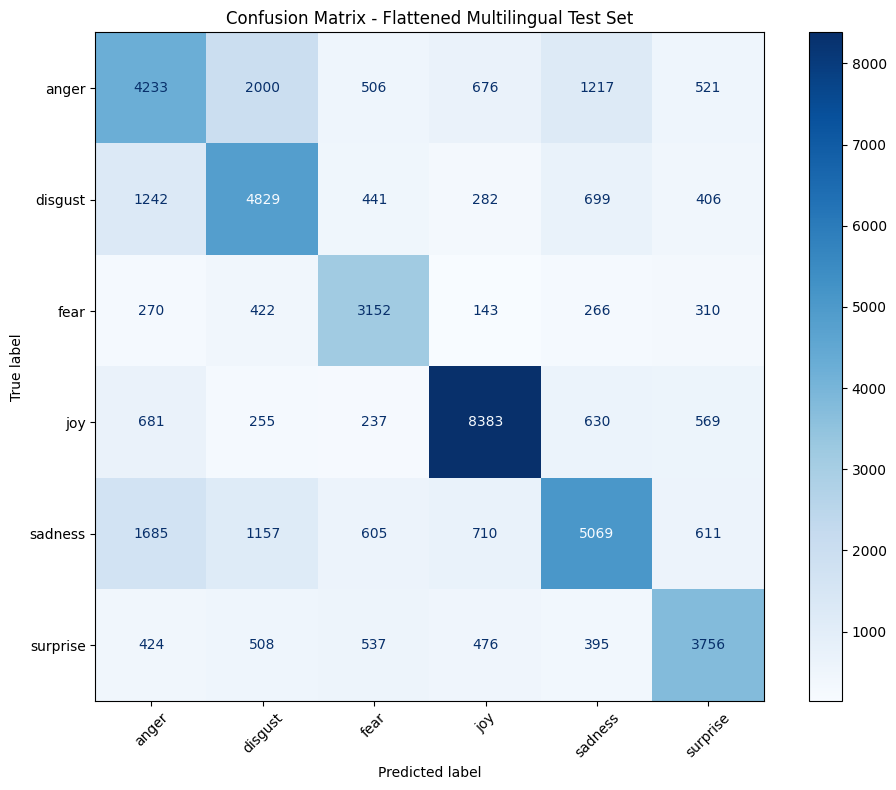

Executed cell #23


In [23]:
# ==========================================================
# CELL 23
# Evaluate the best student model on the test set and plot confusion matrix
# ==========================================================

print("Starting cell #23")
print("Evaluating on test file:", TEST_CSV)

test_metrics = evaluate_classification_model(student_model, flat_test_loader, device)

print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test Macro F1: {test_metrics['macro_f1']:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        test_metrics["y_true"],
        test_metrics["y_pred"],
        target_names=label_encoder.classes_,
        digits=4
    )
)

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix - Flattened Multilingual Test Set")
plt.tight_layout()
plt.show()

print("Executed cell #23")

In [24]:
# ==========================================================
# CELL 24
# Save FP32 and INT8 artifacts and define loading helpers
# Updated for pretrained truncated student reconstruction
# ==========================================================

print("Starting cell #24")
def save_student_artifacts(student_model, tokenizer, label_encoder, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    base_model = get_base_model(student_model)

    fp32_path = os.path.join(save_dir, "student_fp32_state_dict.pt")
    torch.save(base_model.state_dict(), fp32_path)

    config_path = os.path.join(save_dir, "student_arch_config.json")
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(base_model.arch_config, f, indent=2)

    tokenizer_dir = os.path.join(save_dir, "tokenizer")
    tokenizer.save_pretrained(tokenizer_dir)

    label_path = os.path.join(save_dir, "label_encoder.pkl")
    with open(label_path, "wb") as f:
        pickle.dump(label_encoder, f)

    quantized_student = quantize_dynamic(
        copy.deepcopy(base_model).cpu().eval(),
        {nn.Linear},
        dtype=torch.qint8
    )

    int8_path = os.path.join(save_dir, "student_int8_state_dict.pt")
    torch.save(quantized_student.state_dict(), int8_path)

    print(f"Saved FP32 model to: {fp32_path}")
    print(f"Saved INT8 model to: {int8_path}")
    print(f"Saved tokenizer to: {tokenizer_dir}")
    print(f"Saved label encoder to: {label_path}")
    print(f"Saved student config to: {config_path}")

    if os.path.exists(fp32_path):
        print(f"FP32 checkpoint size: {os.path.getsize(fp32_path) / (1024 * 1024):.2f} MB")
    if os.path.exists(int8_path):
        print(f"INT8 checkpoint size: {os.path.getsize(int8_path) / (1024 * 1024):.2f} MB")

    return quantized_student


def load_student_fp32(save_dir, device):
    config_path = os.path.join(save_dir, "student_arch_config.json")
    with open(config_path, "r", encoding="utf-8") as f:
        arch_config = json.load(f)

    tokenizer = AutoTokenizer.from_pretrained(os.path.join(save_dir, "tokenizer"))

    with open(os.path.join(save_dir, "label_encoder.pkl"), "rb") as f:
        label_encoder = pickle.load(f)

    # Reconstruct from config only to avoid any download dependency here
    load_config = copy.deepcopy(arch_config)
    load_config["use_pretrained"] = False

    model = StudentEmotionModel(**load_config)
    state_dict = torch.load(
        os.path.join(save_dir, "student_fp32_state_dict.pt"),
        map_location=device
    )
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()

    if torch.cuda.is_available() and torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    return model, tokenizer, label_encoder


def load_student_int8(save_dir):
    config_path = os.path.join(save_dir, "student_arch_config.json")
    with open(config_path, "r", encoding="utf-8") as f:
        arch_config = json.load(f)

    tokenizer = AutoTokenizer.from_pretrained(os.path.join(save_dir, "tokenizer"))

    with open(os.path.join(save_dir, "label_encoder.pkl"), "rb") as f:
        label_encoder = pickle.load(f)

    load_config = copy.deepcopy(arch_config)
    load_config["use_pretrained"] = False

    model = StudentEmotionModel(**load_config)
    model = quantize_dynamic(
        model.cpu().eval(),
        {nn.Linear},
        dtype=torch.qint8
    )

    state_dict = torch.load(
        os.path.join(save_dir, "student_int8_state_dict.pt"),
        map_location="cpu"
    )
    model.load_state_dict(state_dict)
    model.eval()

    return model, tokenizer, label_encoder


quantized_student_model = save_student_artifacts(
    student_model=student_model,
    tokenizer=tokenizer,
    label_encoder=label_encoder,
    save_dir=SAVE_DIR
)

print("Executed cell #24")

Starting cell #24
Saved FP32 model to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/student_fp32_state_dict.pt
Saved INT8 model to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/student_int8_state_dict.pt
Saved tokenizer to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/tokenizer
Saved label encoder to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/label_encoder.pkl
Saved student config to: /kaggle/working/multilingual_emotion_kd_contrastive_fast/student_arch_config.json
FP32 checkpoint size: 896.23 MB
INT8 checkpoint size: 774.75 MB
Executed cell #24
